In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

Dataset Shape: (50000, 2)

Missing Values:
review       0
sentiment    0
dtype: int64

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


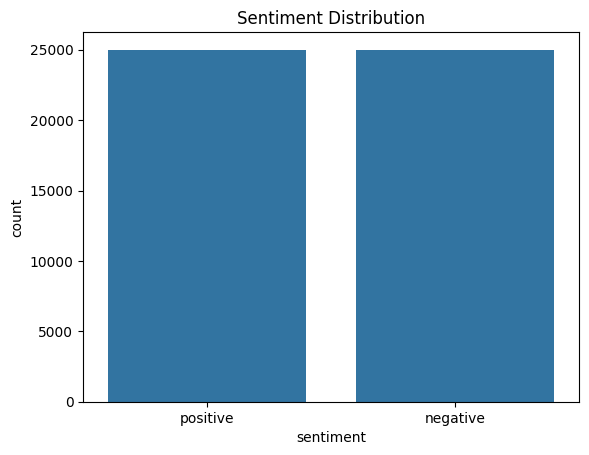

In [4]:
sns.countplot(x="sentiment", data=df)

plt.title("Sentiment Distribution")
plt.show()

In [5]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [6]:
def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r"<.*?>", "", text)
    
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [7]:
df["review"] = df["review"].apply(clean_text)

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [8]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["review"])

y = df["sentiment"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 84.57 %


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



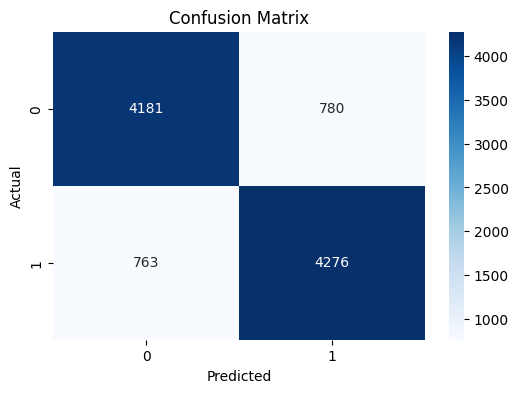

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [16]:
pickle.dump(
    model,
    open("../model/sentiment_model.pkl", "wb")
)

pickle.dump(
    vectorizer,
    open("../model/vectorizer.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully


In [17]:
sample_review = [
    "This movie was absolutely fantastic and amazing"
]

sample_vector = vectorizer.transform(sample_review)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review
